<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/11_Naive_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Naïve 기준모형 (Baseline Model)

**Time Series Analysis | 단순선형회귀 실습 보충자료**

> **학습 목표**  
> 1. Naïve 예측의 정의와 수식을 설명한다.  
> 2. 실제값과 Naïve 예측값의 시점 차이를 시각적으로 확인한다.  
> 3. 회귀·딥러닝 모형의 성능을 기준모형과 비교한다.  
> 4. Naïve와 Random Walk의 개념적 차이를 이해한다.

**진행 방식:** 내용 설명 → 수식 → 실습 코드 → 결과 → 결과 해석  
*아래 TSLA 종가 및 성능 지표는 모두 강의용 가상 예시이며 실제 주가 분석 결과가 아닙니다.*

## 1. Naïve 기준모형이란?

### 내용 설명

**Naïve Forecasting(단순 지속 예측)**은 가장 최근의 실제 관측값을 다음 시점의 예측값으로 사용하는 가장 단순한 예측기법입니다.

- 복잡한 모형 학습이나 파라미터 추정이 필요 없습니다.
- “다음 거래일의 주가가 오늘과 같다”는 예측을 합니다.
- 회귀·머신러닝·딥러닝의 **추가적인 예측 가치**를 평가하기 위한 기준선(Baseline)이 됩니다.

### 수식

$$
\boxed{\hat{Y}_{t+1\mid t}=Y_t}
$$

- $Y_t$: 시점 $t$에 관측된 실제값
- $\hat{Y}_{t+1\mid t}$: 시점 $t$의 정보로 예측한 시점 $t+1$의 값

**내일의 예측값 = 오늘의 실제값**

### 가상 예시: 테슬라(TSLA) 종가

| 거래일 | 실제 종가 (USD) | 다음 거래일의 예측 (USD) |
|:---:|---:|:---|
| 월요일 | 250 | 화요일 250 |
| 화요일 | 255 | 수요일 255 |
| 수요일 | 252 | 목요일 252 |
| 목요일 | 260 | 금요일 260 |

**참고:** 위 수치는 강의 설명을 위한 가상 데이터입니다.

Naïve 예측은 직전 거래일의 실제 종가를 다음 거래일의 예측값으로 사용합니다.

위 표의 숫자는 **실제 주가가 아닌 설명용 가상 데이터**입니다.

### 실습 코드: 실제값과 Naïve 예측선 그리기

아래 코드는 표의 값을 이용해 주가 경로와 Naïve 예측 경로를 비교합니다. 모든 축과 범례는 Colab 한글 글꼴 문제를 피하기 위해 영어로 표시합니다.

,Actual close ($),Naive forecast ($)
Mon,250.0,NaN
Tue,255.0,250.0
Wed,252.0,255.0
Thu,260.0,252.0
Fri,NaN,260.0


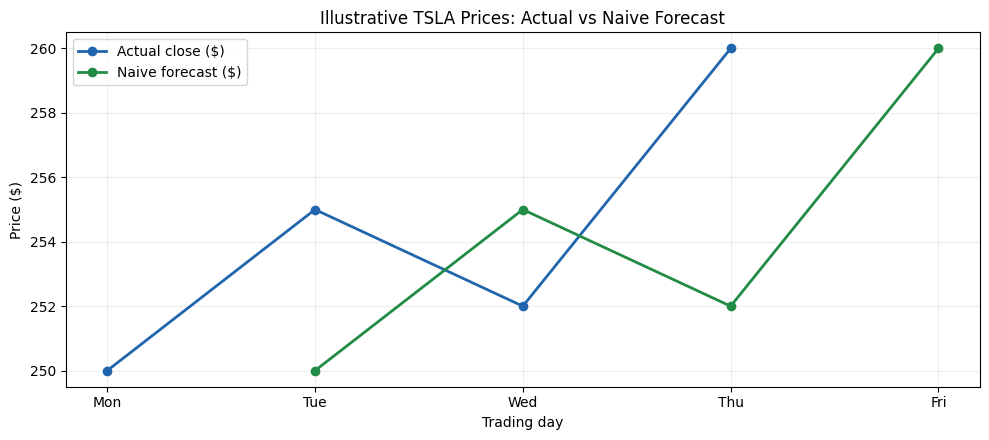

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 강의용 가상 주가 (실제 TSLA 데이터 아님)
days = ["Mon", "Tue", "Wed", "Thu", "Fri"]
actual = pd.Series([250, 255, 252, 260, np.nan], index=days, name="Actual close ($)")

# 해당 요일에 대한 Naive 예측: 직전 거래일의 종가
naive = actual.shift(1).rename("Naive forecast ($)")
comparison = pd.concat([actual, naive], axis=1)
display(comparison)

fig, ax = plt.subplots(figsize=(10, 4.5), facecolor="white")
ax.set_facecolor("white")
ax.plot(days, actual, marker="o", lw=2, label="Actual close ($)", color="#2166ac")
ax.plot(days, naive, marker="o", lw=2, label="Naive forecast ($)", color="#228b45")
ax.set_title("Illustrative TSLA Prices: Actual vs Naive Forecast")
ax.set_xlabel("Trading day")
ax.set_ylabel("Price ($)")
ax.grid(alpha=0.22)
ax.legend()
plt.tight_layout()
plt.show()

### 결과 해석

- 화요일 Naïve 예측 $250$은 월요일 실제 종가 $250$을 그대로 사용합니다.
- 수요일 Naïve 예측 $255$는 화요일 실제 종가 $255$와 같습니다.
- 금요일은 **실제 종가를 제공하지 않았으므로 예측값만 표시**합니다.
- Naïve 예측선은 **실제값이 한 거래일 뒤에 나타나는 형태**로 보입니다. 미래 실제값을 사용한 것이 아닙니다.

> **주의:** 예측 성능을 계산할 때는 반드시 **같은 날짜의 실제값과 예측값**을 비교해야 합니다. 금요일 실제값이 없으므로 금요일은 평가에서 제외합니다.

## 2. 왜 선형회귀 실습에서 Naïve와 비교할까요?

### 내용 설명

복잡한 회귀분석·머신러닝·딥러닝 모형을 사용하더라도, 단순히 직전 값을 반복하는 모형보다 예측오차가 크다면 **그 평가구간에서 추가적인 예측 성능이 입증되지 않은 것**입니다.

가상 비교 결과:

| 모델 | MAE | RMSE |
|---|---:|---:|
| Naïve | 5.20 | 7.10 |
| Linear Regression | 6.40 | 8.30 |
| LSTM | 4.80 | 6.70 |

**위 숫자는 실제 실험 결과가 아닌 예시입니다.** 오차가 작을수록 좋은 성능입니다.


### 수식: 예측오차 지표

**MAE (Mean Absolute Error)**

$$
\mathrm{MAE}=\frac{1}{n}\sum_{t=1}^{n}|Y_t-\hat{Y}_t|
$$

**RMSE (Root Mean Squared Error)**

$$
\mathrm{RMSE}=\left(\frac{1}{n}\sum_{t=1}^{n}(Y_t-\hat{Y}_t)^2\right)^{1/2}
$$
  

### 실습 코드: 모형별 예시 오차 비교

,MAE,RMSE
Model,,
Naive,5.2,7.1
Linear Regression,6.4,8.3
LSTM,4.8,6.7


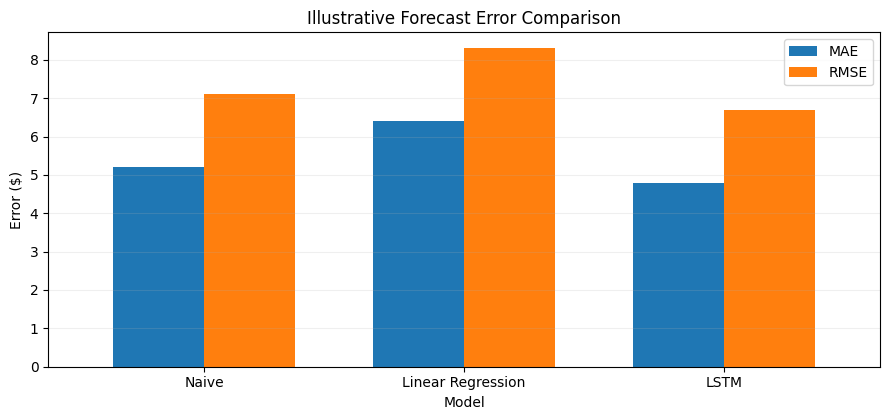

In [2]:
# 아래는 이미 계산된 가상 평가 지표를 시각화하는 코드입니다.
# 실제 모델을 학습하거나 실제 TSLA 데이터를 평가하는 코드가 아닙니다.
scores = pd.DataFrame({
    "Model": ["Naive", "Linear Regression", "LSTM"],
    "MAE": [5.20, 6.40, 4.80],
    "RMSE": [7.10, 8.30, 6.70],
}).set_index("Model")
display(scores)

ax = scores.plot(kind="bar", figsize=(9, 4.3), rot=0, width=0.7)
ax.set_title("Illustrative Forecast Error Comparison")
ax.set_ylabel("Error ($)")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

### 결과 해석

- **Linear Regression**의 MAE $6.40$은 Naïve의 $5.20$보다 큽니다. 이 가상 비교에서는 선형회귀의 성능이 더 나쁩니다.
- **LSTM**의 MAE $4.80$은 Naïve보다 작아 성능 개선이 나타납니다.
- 단, **한 번의 가상 결과로 특정 모형의 일반적인 우수성을 주장할 수 없습니다.** 실제 분석에서는 같은 외표본·같은 예측기간·같은 평가척도로 비교해야 합니다.

> **토론 질문:** 복잡한 선형회귀가 직전 주가를 그대로 사용하는 예측보다 정확하지 않다면, 왜 그 모델을 사용해야 할까요? 예측 목적과 계수 해석 목적의 차이도 생각해 보세요.


## 3. Naïve와 Random Walk의 관계

### 내용 설명

Random Walk(랜덤워크)는 데이터가 어떻게 생성되는지를 설명하는 **확률모형**이고, Naïve는 직전 실제값을 반복하는 **예측 방법**입니다.

### 수식

드리프트가 없는 랜덤워크를 다음과 같이 가정합니다.

$$
Y_{t+1}=Y_t+\epsilon_{t+1}
$$

여기서 정보집합과 오차항은 다음과 같습니다.

- \(I_t\): 시점 \(t\)까지 이용 가능한 정보집합
- \(\epsilon_{t+1}\): 다음 시점의 확률적 오차항

오차항의 조건부 평균이 0이라고 가정합니다.

$$
E(\epsilon_{t+1}\mid I_t)=0
$$

이 조건이 성립한다면 다음과 같습니다.

$$
E(Y_{t+1}\mid I_t)=Y_t
$$

따라서 **제곱오차 기준의 최적 조건부 평균 예측**은 다음과 같습니다.

$$
\hat{Y}_{t+1\mid t}=Y_t
$$

이는 Naïve 예측과 같은 형태입니다.

### 결과 해석

- Random Walk는 시계열의 데이터 생성과정을 설명합니다.
- Naïve는 직전 관측값을 미래의 예측값으로 사용하는 방법입니다.
- 드리프트가 없는 Random Walk에서는 Naïve 예측이 조건부 평균 예측과 일치합니다.
- 그러나 Naïve를 사용한다고 해서 실제 시계열이 반드시 Random Walk를 따른다는 의미는 아닙니다.

**핵심:** Naïve는 예측 방법이고, Random Walk는 확률모형입니다.


## 4. 함께 알아둘 Naïve 유형

| 유형 | 예측 방법 | 활용 사례 |
|---|---|---|
| Simple Naïve | 직전 관측값을 반복 | 주가·환율의 기본 기준선 |
| Seasonal Naïve | 직전 동일 계절의 관측값을 반복 | 월별 전력수요·계절 매출 |
| Drift Method | 관측된 기간의 평균 변화량을 미래로 연장 | 추세가 있는 시계열의 비교모형 |

### 수식: Seasonal Naïve

$$
\hat{Y}_{t+h\mid t}=Y_{t+h-m},\qquad 1\leq h\leq m
$$

- $m$: 계절 주기 (월별 자료에서 연간 계절성은 $m=12$)
- $h$: 예측기간

예: **2025년 1월 예측 = 2024년 1월 실제값** (2024년 12월까지 알고 있을 때).

장기 예측($h>m$)에서는 가장 최근에 관측된 동일 계절의 값을 반복하도록 예측 시점을 주기에 맞춰 확장합니다.

### 수식: Drift Method

$$
\hat{Y}_{t+h\mid t}=Y_t+h\frac{Y_t-Y_1}{t-1},\quad t>1
$$

### 실습 코드: Simple Naïve와 Seasonal Naïve 비교

,Simple naive,Seasonal naive
2026-01,121,102
2026-02,121,110
2026-03,121,114
2026-04,121,107
2026-05,121,101
2026-06,121,117
2026-07,121,122
2026-08,121,123
2026-09,121,111
2026-10,121,105


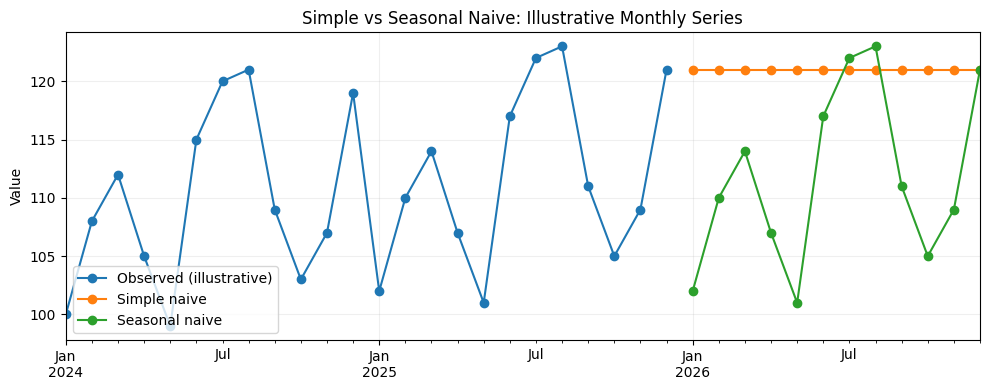

In [3]:
# 월별 가상 데이터로 간단한 기준선 확인 (실제 전력수요 데이터가 아님)
monthly = pd.Series(
    [100, 108, 112, 105, 99, 115, 120, 121, 109, 103, 107, 119,
     102, 110, 114, 107, 101, 117, 122, 123, 111, 105, 109, 121],
    index=pd.period_range("2024-01", periods=24, freq="M"),
    name="Actual"
)

# 2025년 12월까지의 관측치만 알고 2026년 12개월을 예측하는 예
future_index = pd.period_range("2026-01", periods=12, freq="M")
simple_forecast = pd.Series(monthly.iloc[-1], index=future_index, name="Simple naive")
seasonal_forecast = pd.Series(monthly.iloc[-12:].to_numpy(), index=future_index, name="Seasonal naive")
forecast_table = pd.concat([simple_forecast, seasonal_forecast], axis=1)
display(forecast_table)

ax = monthly.plot(figsize=(10, 4), marker="o", label="Observed (illustrative)")
simple_forecast.plot(ax=ax, marker="o", label="Simple naive")
seasonal_forecast.plot(ax=ax, marker="o", label="Seasonal naive")
ax.set_title("Simple vs Seasonal Naive: Illustrative Monthly Series")
ax.set_ylabel("Value")
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

### 결과 해석

- **Simple Naïve**는 예측 출발 시점의 마지막 값(2025년 12월)을 2026년의 모든 월에 반복합니다.
- **Seasonal Naïve**는 2025년의 동일월 관측값을 2026년 각 월의 예측으로 사용합니다.
- 계절성 존재 여부에 따라 성능이 달라질 수 있으므로, 어느 방법이 더 나은지는 실제 외표본 오차를 통해 확인해야 합니다.

## 5. 강의 정리 및 11번 선형회귀 실습 연결

### PPT·강의에 사용할 핵심 요약

- 가장 최근 관측값을 다음 시점의 예측값으로 사용하는 단순 예측기법
- 복잡한 학습이나 파라미터 추정 없이 예측 가능
- 회귀·머신러닝·딥러닝 모형의 추가 예측 가치를 판단하는 기준모형
- 복잡한 모델이 Naïve보다 정확하지 않다면, **해당 평가구간에서** 예측 성능의 개선이 입증되지 않은 것

### 강의 설명 예시

> 여러분, 우리는 지금 선형회귀로 테슬라 주가를 예측하고 있습니다. 그런데 모델을 만들기 전에 간단히 질문해보겠습니다. 내일 주가를 모른다면 그냥 오늘 주가와 같다고 예측하면 어떨까요? 이것이 Naïve 기준모형입니다. 우리의 선형회귀가 이 단순한 예측보다 정확하지 않다면, 복잡한 모델을 사용해도 예측 성능이 개선되었다고 보기 어렵습니다.

### 11_linear_regression.ipynb에서 확인할 사항

1. **예측 대상 날짜**와 실제값의 날짜가 일치하는가?
2. Naïve 예측에 사용한 직전 값이 해당 예측 시점에 **실제로 이용 가능했던 값**인가?
3. Naïve와 선형회귀가 **동일한 외표본 날짜**에서 평가되는가?
4. MAE/RMSE 비교 결과가 기준모형 대비 개선을 보여주는가?

**핵심 메시지:** 좋은 예측모형은 복잡하다는 이유로 가치가 생기지 않습니다. 같은 조건에서 단순 기준모형보다 나은지 먼저 검증해야 합니다.